In [2]:
#Import some things
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import astropy.coordinates as coord
import astropy.units as u
from astropy.io import fits
from astropy.table import Table,join
from astropy.coordinates import SkyCoord
from astropy.io import ascii as asciitable
from unique import unique

In [7]:
data=Table.read('RomanStoneMartinezInterpolate25.out', format='ascii')

In [8]:
data

sdss_id,StoneMartinez2025_Mass,logg,m_h_atm,alpha_m_atm,teff,c_n,StoneMartinez2025_Age,l,b,e_alpha_m_atm,e_teff,sdss4_apogee_id,IntTeff,IntML,IntAge,IntC12,IntC13,IntN14,IntXsurf
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str18,float64,float64,float64,float64,float64,float64,float64
129042025,0.9438877755511023,1.797383189201355,-0.40165001153945923,0.2390582114458084,4175.41552734375,0.02174001932144165,10.072144288577157,359.3968505859375,-1.6111462116241455,0.01492649968713522,12.193188667297363,2M17503205-3017049,4206.5,1.670941,12.65,0.0010857,3.3761e-05,0.00050057,0.70471
82245639,1.2625250501002,2.8121178150177,0.23800000548362732,-0.03523179516196251,4526.32861328125,-0.26231300830841064,7.266533066132265,359.45135498046875,-1.5891793966293335,0.010999999940395355,10.623588562011719,2M17503456-3013361,4530.5,1.717683,5.8631,0.003942,0.00014171,0.0028031,0.66444
82245800,1.3587174348697393,2.2940104007720947,-0.017000000923871994,-0.043231796473264694,4440.98876953125,-0.3999300003051758,3.587587587587588,359.4836120605469,-1.5943197011947632,0.010499999858438969,7.4455885887146,2M17504038-3012058,4423.1,1.753971,3.8425,0.0021791,8.1697e-05,0.001745,0.69379
82245868,1.6472945891783568,2.815610647201538,0.21785999834537506,-0.03861579671502113,4720.28369140625,-0.4141699969768524,3.4054054054054053,359.51788330078125,-1.594736933708191,0.012179950252175331,20.157989501953125,2M17504533-3010205,4607.0,1.90842,2.2039,0.0033785,0.00013555,0.0031659,0.67505
129055734,0.9799599198396796,2.518892526626587,-0.7384300231933594,-0.4123218059539795,4779.7080078125,-0.06681191921234131,5.527054108216433,359.3916320800781,-1.4681634902954102,0.03135799989104271,138.70758056640625,AP17495731-3012558,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0
82247040,1.665330661322645,2.851531505584717,0.3091599941253662,-0.030658794566988945,4722.7646484375,-0.5196700096130371,1.7517517517517518,359.5791015625,-1.5656636953353882,0.012918650172650814,25.283588409423828,2M17504709-3006177,4583.0,1.954841,2.2021,0.0040971,0.00016446,0.0038078,0.66177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125710525,0.9438877755511023,1.6471116542816162,0.3863599896430969,-0.06511979550123215,3599.85888671875,-0.04121202230453491,6.992992992992993,0.09700590372085571,-0.013442705385386944,0.010352689772844315,6.793788909912109,2M17455419-2851372,3869.6,1.307093,19.377,0.0062412,0.00019007,0.0028604,0.64348
129057611,1.1002004008016029,0.7350779175758362,-0.43553000688552856,0.255338191986084,3591.86181640625,-0.26006001234054565,7.371371371371371,359.7882080078125,0.04601288214325905,0.011554449796676636,6.597848892211914,2M17445609-2905342,3665.6,1.592117,7.0897,0.00091429,3.1187e-05,0.00056959,0.70417


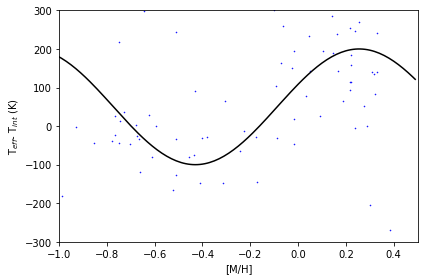

In [10]:
plt.scatter(data['m_h_atm'], data['teff']
            -data['IntTeff'], s=0.3, color='b')
#plt.scatter(data['APOKASC3_M_H'][clump], data['APOKASC3_TEFF'][clump]
#            -data['APOKASC3_TEFFMOD_JT'][clump], s=0.3, color='r')
plt.xlabel('[M/H]')
plt.ylabel('T$_{eff}$- T$_{int}$ (K)')
#plt.colorbar(label='[M/H]')
#plt.text(-0.9, 300, 'RC', color='r')
#plt.text(-0.9, -50, 'RGB', color='b')
mets=np.arange(-1.5, 0.5, 0.01)

plt.plot(mets, 150*np.sin(mets*360/np.pi/25+0.4)+50, 'k-')
#plt.plot([-1.0, 0.0], [100+140], 'k-')

#plt.plot([-0.6, 0.4], [380,210], 'k-')
#plt.plot([-0.25, 0.4], [100,100], 'k-')
#plt.plot([-0.25, -0.8], [100,30], 'k-')
plt.xlim(-1.0, 0.5)
plt.ylim(-300, 300)
plt.tight_layout()        # auto-adjust boundaries after you have added everything
plt.draw()                # make sure it updates (possibly unnecessary)
plt.savefig('teffOffset.jpg', bbox_inches='tight')

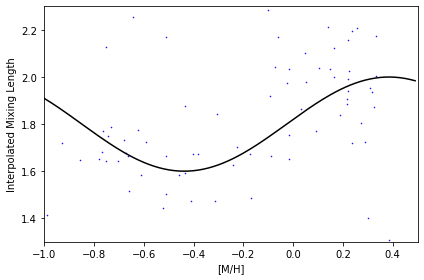

In [11]:
plt.scatter(data['m_h_atm'], data['IntML'], s=0.3, color='b')
#plt.scatter(data['APOKASC3_M_H'][clump], data['APOKASC3_TEFF'][clump]
#            -data['APOKASC3_TEFFMOD_JT'][clump], s=0.3, color='r')
plt.xlabel('[M/H]')
plt.ylabel('Interpolated Mixing Length')
#plt.colorbar(label='[M/H]')
#plt.text(-0.9, 300, 'RC', color='r')
#plt.text(-0.9, -50, 'RGB', color='b')
mets=np.arange(-1.5, 0.5, 0.01)

plt.plot(mets, 0.2*np.sin(mets*12/np.pi+0.1)+1.8, 'k-')
#plt.plot([-1.0, 0.0], [100+140], 'k-')

#plt.plot([-0.6, 0.4], [380,210], 'k-')
#plt.plot([-0.25, 0.4], [100,100], 'k-')
#plt.plot([-0.25, -0.8], [100,30], 'k-')
plt.xlim(-1.0, 0.5)
plt.ylim(1.3, 2.3)
plt.tight_layout()        # auto-adjust boundaries after you have added everything
plt.draw()                # make sure it updates (possibly unnecessary)
plt.savefig('InterpolatedML.jpg', bbox_inches='tight', dpi=600)

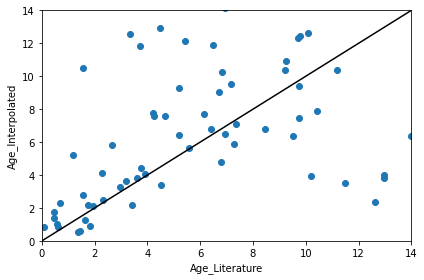

In [13]:
plt.scatter(data['StoneMartinez2025_Age'], data['IntAge'])
plt.xlim(0, 14)
plt.ylim(0, 14)
plt.xlabel('Age_Literature')
plt.ylabel('Age_Interpolated')
plt.plot([0,14], [0,14], 'k-')
plt.tight_layout()        # auto-adjust boundaries after you have added everything
plt.draw()                # make sure it updates (possibly unnecessary)
plt.savefig('Agecompare.jpg', bbox_inches='tight', dpi=600)

In [71]:
#cool so if we put these parameters into the models with the right mixing length, do we get the right ages?

In [15]:
dataNS=Table.read('RomanStoneMartinezInterpolatev25ns3.out', format='ascii')

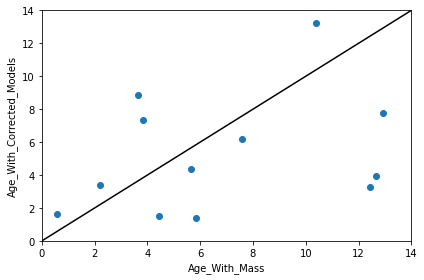

In [16]:
plt.scatter(data['IntAge'], dataNS['IntAge'])
plt.xlim(0, 14)
plt.ylim(0, 14)
plt.xlabel('Age_With_Mass')
plt.ylabel('Age_With_Corrected_Models')
plt.plot([0,14], [0,14], 'k-')
plt.tight_layout()        # auto-adjust boundaries after you have added everything
plt.draw()                # make sure it updates (possibly unnecessary)
plt.savefig('AgecompareMyModels.jpg', bbox_inches='tight', dpi=600)

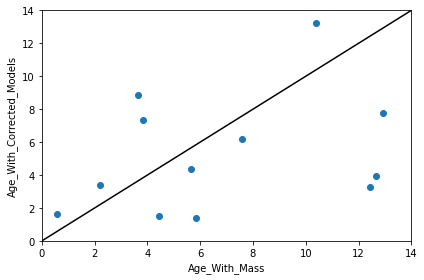

In [17]:
plt.scatter(data['IntAge'], dataNS['IntAge'])
plt.xlim(0, 14)
plt.ylim(0, 14)
plt.xlabel('Age_With_Mass')
plt.ylabel('Age_With_Corrected_Models')
plt.plot([0,14], [0,14], 'k-')
plt.tight_layout()        # auto-adjust boundaries after you have added everything
plt.draw()                # make sure it updates (possibly unnecessary)
plt.savefig('AgecompareMyModels.jpg', bbox_inches='tight', dpi=600)

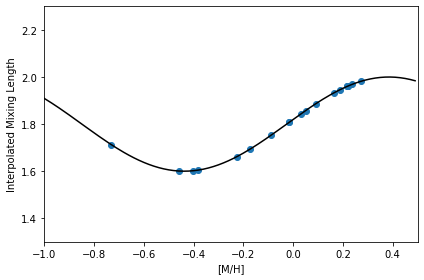

In [19]:
plt.scatter(dataNS['M_H'], dataNS['IntTeff'])
plt.xlim(-1.0, 0.5)
plt.ylim(1.3, 2.3)
mets=np.arange(-1.5, 0.5, 0.01)
plt.plot(mets, 0.2*np.sin(mets*12/np.pi+0.1)+1.8, 'k-')
plt.xlabel('[M/H]')
plt.ylabel('Interpolated Mixing Length')
#plt.plot([0,14], [0,14], 'k-')
plt.tight_layout()        # auto-adjust boundaries after you have added everything
plt.draw()                # make sure it updates (possibly unnecessary)
plt.savefig('SpecMixingLength.jpg', bbox_inches='tight', dpi=600)

In [ ]:
#generate metallicity ranges to make banana

In [81]:
base=Table.read('RomanStoneMartinezInterpolate.txt', format='ascii')

In [82]:
base

sdss_id,StoneMartinez2025_Mass,logg,m_h_atm,alpha_m_atm,teff,c_n,StoneMartinez2025_Age,e_logg,e_m_h_atm,e_alpha_m_atm,e_teff,sdss4_apogee_id
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str18
129042025,0.9438877755511023,1.797383189201355,-0.40165001153945923,0.2390582114458084,4175.41552734375,0.02174001932144165,10.072144288577157,0.04393709450960159,0.014187299646437168,0.01492649968713522,12.193188667297363,2M17503205-3017049
82245639,1.2625250501002,2.8121178150177,0.23800000548362732,-0.03523179516196251,4526.32861328125,-0.26231300830841064,7.266533066132265,0.030825594440102577,0.011500000022351742,0.010999999940395355,10.623588562011719,2M17503456-3013361
82245800,1.3587174348697393,2.2940104007720947,-0.017000000923871994,-0.043231796473264694,4440.98876953125,-0.3999300003051758,3.587587587587588,0.029825594276189804,0.010499999858438969,0.010499999858438969,7.4455885887146,2M17504038-3012058
82245868,1.6472945891783568,2.815610647201538,0.21785999834537506,-0.03861579671502113,4720.28369140625,-0.4141699969768524,3.4054054054054053,0.0338565930724144,0.012185350060462952,0.012179950252175331,20.157989501953125,2M17504533-3010205
129055734,0.9799599198396796,2.518892526626587,-0.7384300231933594,-0.4123218059539795,4779.7080078125,-0.06681191921234131,5.527054108216433,0.0941355973482132,0.02455350011587143,0.03135799989104271,138.70758056640625,AP17495731-3012558
82247040,1.665330661322645,2.851531505584717,0.3091599941253662,-0.030658794566988945,4722.7646484375,-0.5196700096130371,1.7517517517517518,0.03563959524035454,0.012854299508035183,0.012918650172650814,25.283588409423828,2M17504709-3006177
...,...,...,...,...,...,...,...,...,...,...,...,...
125710525,0.9438877755511023,1.6471116542816162,0.3863599896430969,-0.06511979550123215,3599.85888671875,-0.04121202230453491,6.992992992992993,0.03001389466226101,0.010997200384736061,0.010352689772844315,6.793788909912109,2M17455419-2851372
129057611,1.1002004008016029,0.7350779175758362,-0.43553000688552856,0.255338191986084,3591.86181640625,-0.26006001234054565,7.371371371371371,0.032354194670915604,0.011187699623405933,0.011554449796676636,6.597848892211914,2M17445609-2905342


In [83]:
base['m_h_atm']=base['m_h_atm']*0.0-1.0

In [84]:
base

sdss_id,StoneMartinez2025_Mass,logg,m_h_atm,alpha_m_atm,teff,c_n,StoneMartinez2025_Age,e_logg,e_m_h_atm,e_alpha_m_atm,e_teff,sdss4_apogee_id
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str18
129042025,0.9438877755511023,1.797383189201355,-1.0,0.2390582114458084,4175.41552734375,0.02174001932144165,10.072144288577157,0.04393709450960159,0.014187299646437168,0.01492649968713522,12.193188667297363,2M17503205-3017049
82245639,1.2625250501002,2.8121178150177,-1.0,-0.03523179516196251,4526.32861328125,-0.26231300830841064,7.266533066132265,0.030825594440102577,0.011500000022351742,0.010999999940395355,10.623588562011719,2M17503456-3013361
82245800,1.3587174348697393,2.2940104007720947,-1.0,-0.043231796473264694,4440.98876953125,-0.3999300003051758,3.587587587587588,0.029825594276189804,0.010499999858438969,0.010499999858438969,7.4455885887146,2M17504038-3012058
82245868,1.6472945891783568,2.815610647201538,-1.0,-0.03861579671502113,4720.28369140625,-0.4141699969768524,3.4054054054054053,0.0338565930724144,0.012185350060462952,0.012179950252175331,20.157989501953125,2M17504533-3010205
129055734,0.9799599198396796,2.518892526626587,-1.0,-0.4123218059539795,4779.7080078125,-0.06681191921234131,5.527054108216433,0.0941355973482132,0.02455350011587143,0.03135799989104271,138.70758056640625,AP17495731-3012558
82247040,1.665330661322645,2.851531505584717,-1.0,-0.030658794566988945,4722.7646484375,-0.5196700096130371,1.7517517517517518,0.03563959524035454,0.012854299508035183,0.012918650172650814,25.283588409423828,2M17504709-3006177
...,...,...,...,...,...,...,...,...,...,...,...,...
125710525,0.9438877755511023,1.6471116542816162,-1.0,-0.06511979550123215,3599.85888671875,-0.04121202230453491,6.992992992992993,0.03001389466226101,0.010997200384736061,0.010352689772844315,6.793788909912109,2M17455419-2851372
129057611,1.1002004008016029,0.7350779175758362,-1.0,0.255338191986084,3591.86181640625,-0.26006001234054565,7.371371371371371,0.032354194670915604,0.011187699623405933,0.011554449796676636,6.597848892211914,2M17445609-2905342


In [86]:
base.write('RomanSM_'+str(-1.0)+'.txt', format='ascii')

In [91]:
for i in range(15):
    j=i*0.1-1.0
    print(j)
    base['m_h_atm']=base['m_h_atm']*0.0+j
    base.write('RomanSM_'+str(j)+'.txt', format='ascii')

-1.0
-0.9
-0.8
-0.7
-0.6
-0.5
-0.3999999999999999
-0.29999999999999993
-0.19999999999999996
-0.09999999999999998
0.0
0.10000000000000009
0.20000000000000018
0.30000000000000004
0.40000000000000013
